In [ ]:
!pip show torch
!pip install rdkit
!pip install torch_geometric
!pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Name: torch
Version: 2.6.0+cu124
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvtx-cu12, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html


In [ ]:
import pickle
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv,global_mean_pool, BatchNorm, radius_graph
from torch_geometric.data import Data
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
project_path = '/content/drive/My Drive/Colab Notebooks'
os.chdir(project_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [ ]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#fe_scaled = scaler.fit_transform(fe.reshape(-1, 1)).flatten()

In [ ]:
print(np.min(fe), np.max(fe), np.mean(fe), np.std(fe))

-3.5815375 6.492535 0.0004583929 1.0020696


In [ ]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [ ]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  O  │  8   │     0.079│     1.372│     0.221
  C  │  6   │     0.050│    -0.030│     0.065
  C  │  6   │    -1.378│    -0.553│    -0.040
  C  │  6   │    -1.466│    -2.073│    -0.216
  C  │  6   │    -2.842│    -2.621│     0.163
  C  │  6   │    -3.200│    -2.807│     1.620
  C  │  6   │    -3.850│    -1.706│     0.828
  C  │  6   │    -3.438│    -0.270│     1.083
  O  │  8   │    -2.028│    -0.133│     1.163
  H  │  1   │    -0.557│     1.563│     0.921
  H  │  1   │     0.601│    -0.270│    -0.851
  H  │  1   │     0.551│    -0.542│     0.903
  H  │  1   │    -1.874│    -0.052│    -0.888
  H  │  1   │    -1.246│    -2.314│    -1.261
  H  │  1   │    -0.690│    -2.558│     0.389
  H  │  1   │    -3.244│    -3.362│    -0.521
  H  │  1   │    -3.798│    -3.666│     1.902
  H  │  1   │    -2.450│    -2.515│     2.349
  H  │  1   │    -4.894│    -1.828│     0.558
  H  │  1   │    -3.829│     0.380

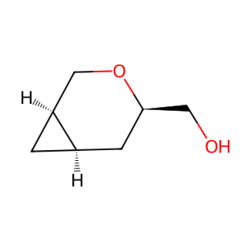

In [ ]:

# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

TASK1:GEOMETRIC REPRESENTATION: Here, we are given only pos,type of each molecule. We will infer bond information heuristically, and create a graph for each molecule and give it to a GCN which also has FC layers, and output task is regression.

Creating a MODEL

The model i started with had only 2 layers without any overfitting mechanisms but the huge dataset required me to add dropouts, decay, batch normalization and additional 1 layer of gcn.

In [ ]:
class geometric_GCN(nn.Module):
    def __init__(self,in_dim,emd_dim=128,dropout=0.5):
        super().__init__()
        self.gcn1 = GCNConv(in_dim,emd_dim) # input:in_dim-> output: emb_dim
        self.bn1  = BatchNorm(emd_dim)
        self.gcn2 = GCNConv(emd_dim,emd_dim)
        self.bn2  = BatchNorm(emd_dim)
        #self.gcn3 = GCNConv(emd_dim,emd_dim)
        #self.bn3  = BatchNorm(emd_dim)
        self.fc = nn.Linear(emd_dim,1) # output task
        self.dropout = nn.Dropout(p=dropout)

    def forward(self,data): # get data as graph
        x,edge_index = data.x,data.edge_index
        batch = getattr(data, 'batch', torch.zeros(x.size(0), dtype=torch.long, device=x.device))
        x = self.gcn1(x,edge_index) # [x: num_nodes,one_hot_dim+3]
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.gcn2(x,edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        #x = self.gcn3(x,edge_index)
        #x = self.bn3(x)
        #x = F.relu(x)
        #x = self.dropout(x)

        x = global_mean_pool(x,batch) #aggregates nodes into single vector/graph for fc
        x = self.fc(x)
        return x.view(-1)

Extract train, test, formation energy data

In [ ]:
train_data = [list(zip(pos_data[i],type_data[i])) for i in train_idxes]
test_data  = [list(zip(pos_data[i],type_data[i])) for i in test_idxes]
train_fe = [fe[i] for i in train_idxes]
test_fe  = [fe[i] for i in test_idxes]

Steps for creating a graph for each molecule:
1. I have assumed that we may not know which atom exists. So, as and when new atom is seen, it gets updated in dictionary, which is then used for one hot encoding.
2. This one hot encoding per atom and based on distances between the atoms, I have created a graph build function.

In [ ]:
def global_dict(dataset):
    unique_atoms = set()
    for mol in dataset:
        _, types = zip(*mol)
        unique_atoms.update(types)
    sorted_types = sorted(unique_atoms)
    return {t: i for i, t in enumerate(sorted_types)}

atom_idx = global_dict(train_data+test_data)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
#def build_graph(molecule, fe, threshold=1.8):
#    atom_pos, atom_type = zip(*molecule)
#
#    # Features of the node
#    x = torch.tensor([atom_idx[i] for i in atom_type], dtype=torch.long)
#    x = F.one_hot(x, num_classes=len(atom_idx)).float()
#    pos = torch.tensor(atom_pos, dtype=torch.float)
#
#    # Determining edges based on distance and having no edge attributes
#    #edge_index = []
#    #for i in range(len(pos)):
#    #    for j in range(i + 1, len(pos)):
#    #        dist = torch.norm(pos[i] - pos[j])
#    #        if dist < threshold:
#    #            edge_index.extend([[i, j], [j, i]])  # undirected
#
#    #edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
#    #x = torch.cat([x, pos], dim=1)  # concat one-hot + (x, y, z)
#
#    # Creating edge attribute based on distance. ie now we store interatomic distance as edge attribute.
#    # dists>0 is used to exclude self loop : online
#    dists = torch.cdist(pos,pos,p=2)
#    src,dst = torch.where ((dists<threshold) & (dists>0))
#    edge_index = torch.stack([src,dst],dim=0)
#    edge_attr = dists[src,dst].unsqueeze(1)
#
#    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr,y=torch.tensor([fe], dtype=torch.float))
#

def build_graph(molecule, fe, threshold=5.0):  # You can change threshold as needed
    atom_pos, atom_type = zip(*molecule)

    # Node features
    x = torch.tensor([atom_idx[i] for i in atom_type], dtype=torch.long)
    x = F.one_hot(x, num_classes=len(atom_idx)).float()
    pos = torch.tensor(atom_pos, dtype=torch.float)

    # Use radius_graph to build edge_index (undirected by default if loop=False)
    edge_index = radius_graph(pos, r=threshold, loop=False)

    # Optional: add edge attributes (distance between connected atoms)
    dists = torch.cdist(pos, pos, p=2)  # shape [num_nodes, num_nodes]
    src, dst = edge_index
    edge_attr = dists[src, dst].unsqueeze(1)  # shape [num_edges, 1]

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=torch.tensor([fe], dtype=torch.float), pos=pos)

In [ ]:
train_graphs = [build_graph(m,e) for m,e in zip(train_data,train_fe)]
test_graphs  = [build_graph(m,e) for m,e in zip(test_data,test_fe)]

Training and Testing on the data

In [ ]:
def train(model,train_loader,optimizer,loss_fn):
  model.train()
  total_loss =0
  for batch in train_loader:
    batch =batch.to(device)
    optimizer.zero_grad() # dont store the gradients
    out = model(batch)
    loss = loss_fn(out,batch.y.view(-1))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()*batch.num_graphs #item converts loss into python since total_loss is python variable
  return total_loss/len(train_loader.dataset)

def test(model,loader,loss_fn):
  model.eval()
  total_loss =0
  preds = []
  ground_truth = []
  with torch.no_grad():
    for batch in test_loader:
      batch=batch.to(device)
      out = model(batch)
      loss = loss_fn(out,batch.y.view(-1))
      total_loss += loss.item()*batch.num_graphs
      preds.append(out)
      ground_truth.append(batch.y.view(-1))

  preds = torch.cat(preds)
  ground_truth = torch.cat(ground_truth)
  preds = preds.cpu().numpy().reshape(-1, 1)
  ground_truth = ground_truth.cpu().numpy().reshape(-1, 1)
  #preds_inv = scaler.inverse_transform(preds).flatten()
  #trues_inv = scaler.inverse_transform(ground_truth).flatten()
  return total_loss/len(loader.dataset),preds,ground_truth



EARLY STOPPING CODE: Chatgpt

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            #if self.verbose:
            #    print(f" New best loss: {val_loss:.4f}")
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement. Patience {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


In [ ]:
from torch_geometric.loader import DataLoader
train_loader = DataLoader(train_graphs,batch_size=32,shuffle=True)
test_loader = DataLoader(test_graphs,batch_size=32,shuffle=True)

#loss_fn = nn.MSELoss()
loss_fn = nn.SmoothL1Loss(beta=1.0)
model = geometric_GCN(in_dim=train_graphs[0].x.size(1),emd_dim=128,dropout=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)


early_stopping = EarlyStopping(patience=4,verbose=True)
for epoch in range(1,20):
    train_loss = train(model,train_loader,optimizer,loss_fn)
    test_loss,preds,trues = test(model, test_loader,loss_fn)
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    early_stopping(test_loss,model)
    if early_stopping.early_stop:
      print(f"\n Early stoppign at epoch {epoch}. Best test loss achieved is {early_stopping.best_loss}")
      break

model.load_state_dict(early_stopping.best_model_state)

Epoch 01 | Train Loss: 0.1044 | Test Loss: 0.0838
✅ New best loss: 0.0838
Epoch 02 | Train Loss: 0.0984 | Test Loss: 0.0761
✅ New best loss: 0.0761
Epoch 03 | Train Loss: 0.0956 | Test Loss: 0.0731
✅ New best loss: 0.0731
Epoch 04 | Train Loss: 0.0921 | Test Loss: 0.0756
⏳ No improvement. Patience 1/4
Epoch 05 | Train Loss: 0.0906 | Test Loss: 0.0660
✅ New best loss: 0.0660
Epoch 06 | Train Loss: 0.0894 | Test Loss: 0.0822
⏳ No improvement. Patience 1/4
Epoch 07 | Train Loss: 0.0895 | Test Loss: 0.0799
⏳ No improvement. Patience 2/4
Epoch 08 | Train Loss: 0.0882 | Test Loss: 0.0595
✅ New best loss: 0.0595
Epoch 09 | Train Loss: 0.0883 | Test Loss: 0.0686
⏳ No improvement. Patience 1/4
Epoch 10 | Train Loss: 0.0872 | Test Loss: 0.0627
⏳ No improvement. Patience 2/4
Epoch 11 | Train Loss: 0.0879 | Test Loss: 0.0646
⏳ No improvement. Patience 3/4
Epoch 12 | Train Loss: 0.0876 | Test Loss: 0.0737
⏳ No improvement. Patience 4/4

 Early stoppign at epoch 12. Best test loss achieved is 0.0594

<All keys matched successfully>

In [ ]:
# Ensure numpy arrays
from sklearn.linear_model import LinearRegression
trues_np = np.array(trues).reshape(-1, 1)
preds_np = np.array(preds).reshape(-1, 1)

# Fit linear regression
reg = LinearRegression().fit(trues_np, preds_np)
line_x = np.linspace(trues_np.min(), trues_np.max(), 100).reshape(-1, 1)
line_y = reg.predict(line_x)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(trues_np, preds_np, alpha=0.5, label='Predicted vs True')
plt.plot(line_x, line_y, color='red', linewidth=2, label='Best-fit Line')
plt.plot(line_x, line_x, color='black', linestyle='--', label='Ideal: y = x')
plt.xlabel('True Formation Energy')
plt.ylabel('Predicted Formation Energy')
plt.title('Formation Energy: Prediction vs True')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
#r2 = r2_score(trues, preds)
#mae = mean_absolute_error(trues, preds)
#print(r2)
#print(mae)

# Denormalize
trues_denorm = np.array(trues) * std + mu
preds_denorm = np.array(preds) * std + mu

# Compute metrics in original units
r2 = r2_score(trues_denorm, preds_denorm)
mae = mean_absolute_error(trues_denorm, preds_denorm)

print(f"R² score: {r2:.4f}")
print(f"MAE (eV): {mae:.4f}")

R² score: 0.8395
MAE (eV): 2.4531


In [ ]:
from scipy.stats import pearsonr

r, _ = pearsonr(trues_denorm.squeeze(), preds_denorm.squeeze())
print(f"Pearson r: {r:.4f}")

NameError: name 'trues_denorm' is not defined